In [13]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [14]:
# Fetch historical data
symbol = 'RTX'
start_date = '2023-01-01'
end_date = '2024-04-30'
data = yf.download(symbol, start=start_date, end=end_date)

[*********************100%%**********************]  1 of 1 completed


In [15]:
def rsi(data, period):
    delta = data.diff().dropna()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs)) # Calculate the 14-day RSI
data['RSI'] = rsi(data['Close'], 14)

In [16]:
data['Signal'] = 0
data.loc[(data['RSI'] < 30) & (data.RSI.shift(-1) > 30), 'Signal'] = 1
data.loc[(data['RSI'] > 70) & (data.RSI.shift(-1) < 70), 'Signal'] = -1

# Backtest

<Axes: xlabel='Date'>

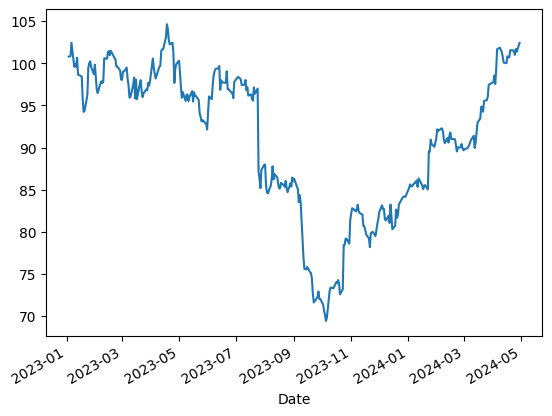

In [17]:
data["Close"].plot()

In [18]:
initial_capital = 500

In [19]:
data['Daily_Return'] = data['Close'].pct_change()

data['positions'] = 1 * data['Signal'].cumsum() * data['Close']
data['cash'] = initial_capital - (1 * data['Signal'] * data["Close"]).cumsum()
data["networth"] = data["positions"] + data["cash"]

# cash = initial_capital - (buy_sell_signal * security_data['Adj Close']).cumsum()  # Calculate the cash over time
# positions = buy_sell_signal.cumsum() * security_data['Adj Close']  # Calculate the positions over time
# networth = positions + cash # Calculate the total value of the portfolio over time


In [20]:
data

,Open,High,Low,Close,Adj Close,Volume,RSI,Signal,Daily_Return,positions,cash,networth
Date,,,,,,,,,,,,
2023-01-03,100.989998,101.230003,100.099998,100.809998,97.005157,3532300,NaN,0,NaN,0.000000,500.000000,500.000000
2023-01-04,100.510002,102.099998,100.410004,100.839996,97.034027,5635100,NaN,0,0.000298,0.000000,500.000000,500.000000
2023-01-05,100.269997,101.459999,99.660004,100.879997,97.072525,4967200,NaN,0,0.000397,0.000000,500.000000,500.000000
2023-01-06,101.900002,103.949997,101.300003,102.459999,98.592880,6411700,NaN,0,0.015662,0.000000,500.000000,500.000000
2023-01-09,102.730003,102.779999,98.779999,99.599998,95.840828,6377300,NaN,0,-0.027913,0.000000,500.000000,500.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-23,101.000000,103.889999,99.879997,101.379997,100.773735,8568200,73.439404,-1,-0.001772,-304.139992,835.460007,531.320015
2024-04-24,101.720001,101.889999,100.010002,101.019997,100.415886,7722100,62.629246,0,-0.003551,-303.059990,835.460007,532.400017
2024-04-25,100.900002,101.879997,100.589996,101.709999,101.101768,6186100,50.196818,0,0.006830,-305.129997,835.460007,530.330009


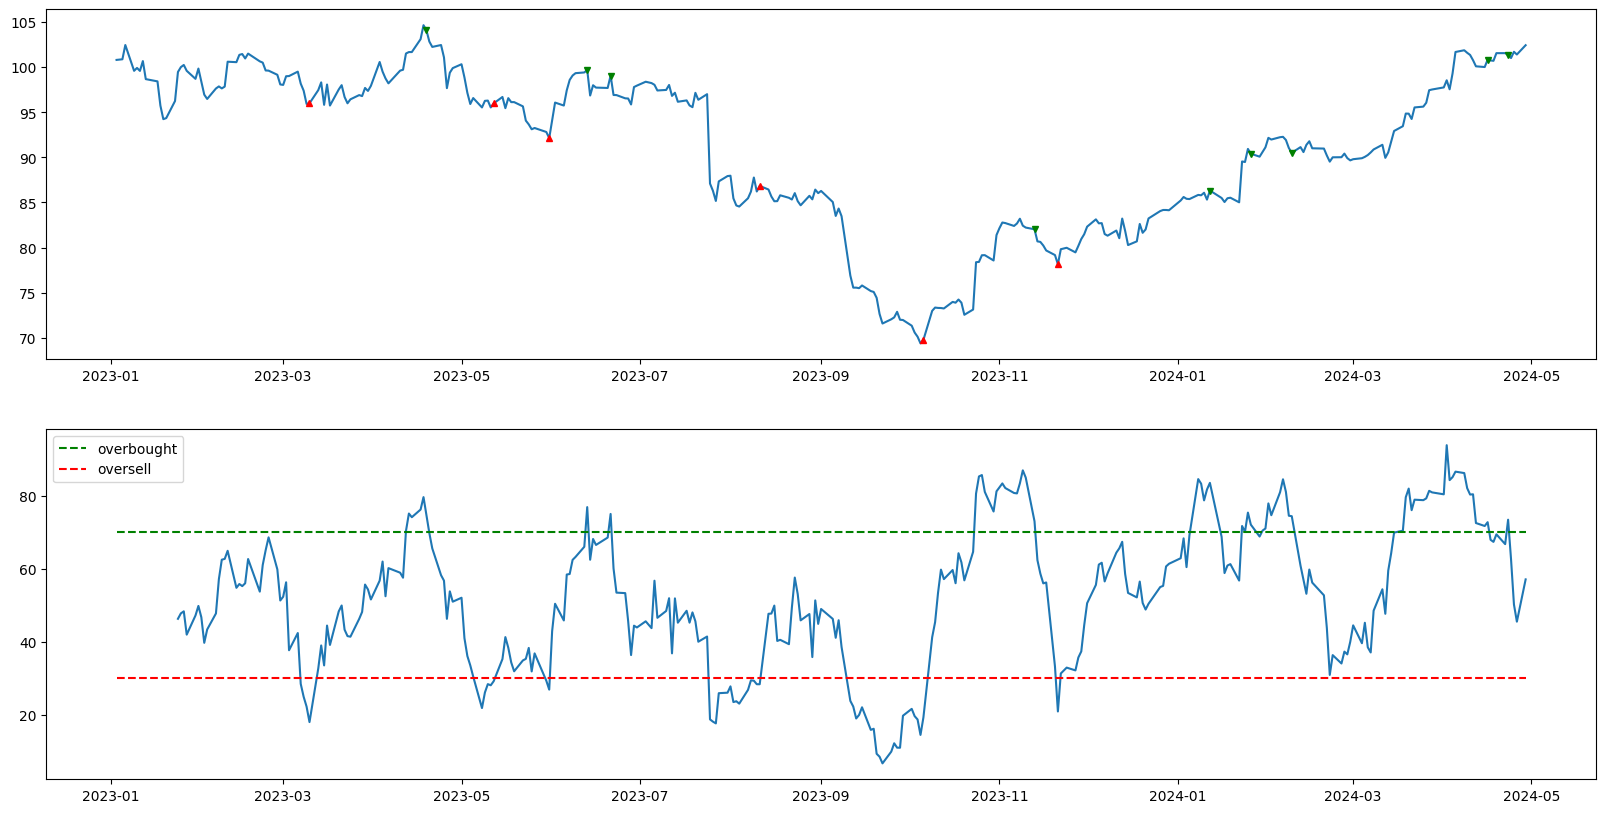

In [21]:
# @title Close

from matplotlib import pyplot as plt
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
ax1.plot(data.Close)
ax1.plot(data.loc[data.Signal == 1.0].index, data.Close[data.Signal == 1.0], '^', markersize=5, color='r', label="Buy")
ax1.plot(data.loc[data.Signal == -1.0].index, data.Close[data.Signal == -1.0], 'v', markersize=5, color='g', label="Sell")

ax2 = fig.add_subplot(212)
ax2.plot(data.RSI)
ax2.hlines(70, xmin=data.index[0], xmax=data.index[-1], linestyles="dashed", color="g", label="overbought")
ax2.hlines(30, xmin=data.index[0], xmax=data.index[-1], linestyles="dashed", color="r", label="oversell")



plt.legend()
plt.show()

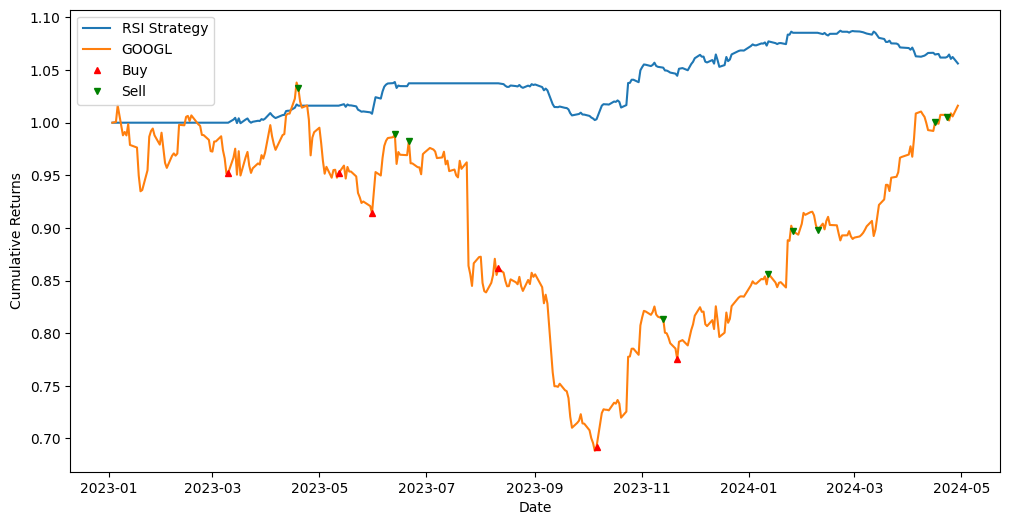

In [22]:
# Plot both cumulative returns on the same chart
plt.figure(figsize=(12, 6))
plt.plot(data.index, data.networth / data.networth.iloc[0], label='RSI Strategy')
plt.plot(data.index, data.Close / data.Close.iloc[0], label='GOOGL')

plt.plot(data.loc[data.Signal == 1.0].index, (data.Close / data.Close.iloc[0])[data.Signal == 1.0], '^', markersize=5, color='r', label="Buy")
plt.plot(data.loc[data.Signal == -1.0].index, (data.Close / data.Close.iloc[0])[data.Signal == -1.0], 'v', markersize=5, color='g', label="Sell")


plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

In [23]:
def sharpe_ratio(rate):
    r_f = 0.005 / 252  # 0.5% (US Treasury)

    r_m = rate.mean()
    sigma = rate.std()

    return (r_m - r_f) / sigma

In [24]:
print("Sharpe ratio:")
print("RSI Strategy", sharpe_ratio(data['networth'].pct_change()))
print("Buy and hold", sharpe_ratio(data['Close'].pct_change()))


Sharpe ratio:
RSI Strategy 0.0584204640046088
Buy and hold 0.009059717614587657
